In [12]:
## requirements ##
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import chess, chess.pgn
import os
import io
import time

In [13]:
## data paths ##
DATA_ROOT = os.environ['DATA_ROOT']
DATA_JAN2023 = os.path.join(
    DATA_ROOT,
    "lichess-01-23"
)
DATA_SAMPLES = os.path.join(
    DATA_JAN2023,
    "samples"
)
MAIN_DATA_FILE = os.path.join(
    DATA_JAN2023,
    "lichess_db_standard_rated_2023-01.pgn"
)
FULL_DATASET_DIR = os.path.join(
    DATA_JAN2023,
    "full"
)
TINY_SAMPLE_FILE = os.path.join(
    DATA_SAMPLES,
    "tiny_sample.parquet"
)
SMALL_SAMPLE_FILE = os.path.join(
    DATA_SAMPLES,
    "small_sample.parquet"
)
MEDIUM_SAMPLE_FILE = os.path.join(
    DATA_SAMPLES,
    "medium_sample.parquet"
)
LARGE_SAMPLE_FILE = os.path.join(
    DATA_SAMPLES,
    "large_sample.parquet"
)
HUGE_SAMPLE_FILE = os.path.join(
    DATA_SAMPLES,
    "huge_sample.parquet"
)
print("DATA ROOT PATH: ", DATA_ROOT)
print("DATA JAN2023 PATH: ", DATA_JAN2023)
print("DATA SAMPLES PATH: ", DATA_SAMPLES)


DATA ROOT PATH:  /Users/ashishneupane/data
DATA JAN2023 PATH:  /Users/ashishneupane/data/lichess-01-23
DATA SAMPLES PATH:  /Users/ashishneupane/data/lichess-01-23/samples


In [14]:
## data utilities ##
def load_sample_data(sample_file: str):
    df = pd.read_parquet(sample_file)
    print("Loaded {} rows from {}".format(len(df), sample_file))
    return df

def load_random_game(df: pd.DataFrame):
    """ 
    Load a random game from a dataframe of games in chess.pgn.Game format.
    :param df: dataframe of games
    :return: chess.pgn.Game
    """
    game_index = np.random.randint(0, len(df))
    game = df.iloc[game_index]
    game_dict = game.to_dict()
    game = chess.pgn.read_game(io.StringIO(game_dict['moves']))
    del game_dict['moves']
    for key in game_dict:
        if game_dict[key] is not None:
            game.headers[key] = game_dict[key]
    return game

In [15]:
df_games = load_sample_data(TINY_SAMPLE_FILE)
df_games.head()

Loaded 1000 rows from /Users/ashishneupane/data/lichess-01-23/samples/tiny_sample.parquet


,Event,Site,Date,Round,White,Black,Result,BlackElo,BlackRatingDiff,ECO,Opening,Termination,TimeControl,UTCDate,UTCTime,WhiteElo,WhiteRatingDiff,moves,WhiteTitle,BlackTitle
0,Rated Blitz game,https://lichess.org/CTPSkrMn,2023.01.02,-,JovanRusqui,VenZky,1-0,1304,-9,C44,Scotch Game: Lolli Variation,Time forfeit,180+0,2023.01.02,05:27:19,1343,+5,1. e4 { [%clk 0:03:00] } 1... e5 { [%clk 0:03:...,None,None
1,Rated Blitz game,https://lichess.org/M5yplVvF,2023.01.01,-,MrLahey,volerman,1-0,2016,-6,B10,Caro-Kann Defense: Two Knights Attack,Normal,300+0,2023.01.01,06:08:41,2051,+5,1. e4 { [%clk 0:05:00] } 1... c6 { [%clk 0:05:...,None,None
2,Rated Rapid game,https://lichess.org/9XXFssyy,2023.01.02,-,Maslenkov_Sergey,Paradox23,1-0,1391,-5,C57,"Italian Game: Two Knights Defense, Knight Atta...",Normal,900+3,2023.01.02,09:25:48,1460,+6,1. e4 { [%clk 0:15:00] } 1... e5 { [%clk 0:15:...,None,None
3,Rated Bullet game,https://lichess.org/kGceaIeL,2023.01.01,-,rafraf396,Harry20209,1-0,1570,-6,A43,Benoni Defense: French Benoni,Time forfeit,60+0,2023.01.01,09:09:53,1566,+6,1. e4 { [%clk 0:01:00] } 1... c5 { [%clk 0:01:...,None,None
4,Rated Bullet game,https://lichess.org/cP9Bizxs,2023.01.02,-,HusseNHamdy,ChristianHG,0-1,1185,+5,A00,Van't Kruijs Opening,Normal,60+0,2023.01.02,01:47:02,1135,-4,1. e3 { [%eval 0.0] [%clk 0:01:00] } 1... e5 {...,None,None


In [37]:
game = load_random_game(df_games)
board = game.board()
#display(board)
print(game.mainline_moves())
# for move in game.mainline_moves():
#     board.push(move)
#     display(board)

{'Event': 'Rated Blitz tournament https://lichess.org/tournament/lldFAgeL', 'Site': 'https://lichess.org/ClJCrXJn', 'Date': '2023.01.02', 'Round': '-', 'White': 'Alex_Amatonding', 'Black': 'shatranje', 'Result': '0-1', 'BlackElo': '2105', 'BlackRatingDiff': '+6', 'ECO': 'A03', 'Opening': 'Bird Opening: Dutch Variation', 'Termination': 'Normal', 'TimeControl': '180+0', 'UTCDate': '2023.01.02', 'UTCTime': '10:36:05', 'WhiteElo': '2129', 'WhiteRatingDiff': '-6', 'WhiteTitle': None, 'BlackTitle': None}
1. f4 { [%clk 0:03:00] } 1... d5 { [%clk 0:03:00] } 2. Nf3 { [%clk 0:02:59] } 2... g6 { [%clk 0:02:59] } 3. e3 { [%clk 0:02:58] } 3... Bg7 { [%clk 0:02:58] } 4. d4 { [%clk 0:02:58] } 4... e6 { [%clk 0:02:56] } 5. Bd3 { [%clk 0:02:57] } 5... f5 { [%clk 0:02:56] } 6. O-O { [%clk 0:02:56] } 6... Nf6 { [%clk 0:02:55] } 7. Nbd2 { [%clk 0:02:56] } 7... O-O { [%clk 0:02:54] } 8. c3 { [%clk 0:02:55] } 8... Nbd7 { [%clk 0:02:53] } 9. Qe1 { [%clk 0:02:54] } 9... Ne4 { [%clk 0:02:49] } 10. Ne5 { [%clk 

# plot some data stats

Text(0.5, 1.0, 'BlackElo distribution')

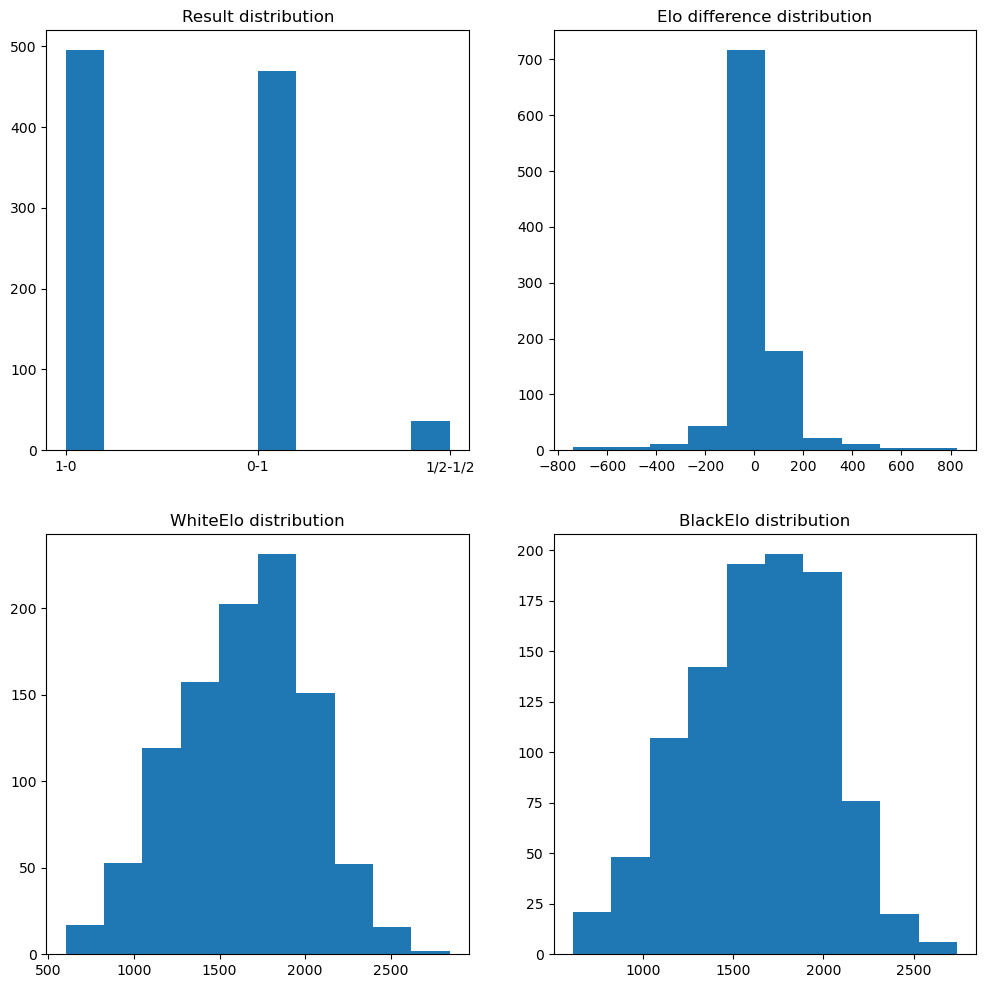

In [33]:
fig = plt.figure()
fig.set_figheight(12)
fig.set_figwidth(12)

# result
ax1 = plt.subplot(221)
ax1.hist(df_games["Result"])
ax1.set_title("Result distribution")

# elos
white_elo = [int(elo) if elo is not None else -1 for elo in df_games["WhiteElo"]]
black_elo = [int(elo) if elo is not None else -1 for elo in df_games["BlackElo"]]
ax2 = plt.subplot(222)
ax2.hist(np.array(white_elo) - np.array(black_elo), 10)
ax2.set_title("Elo difference distribution")
ax3 = plt.subplot(223)
ax3.hist(white_elo, 10)
ax3.set_title("WhiteElo distribution")
ax4 = plt.subplot(224)
ax4.hist(black_elo, 10)
ax4.set_title("BlackElo distribution")

Text(0.5, 1.0, 'Termination distribution')

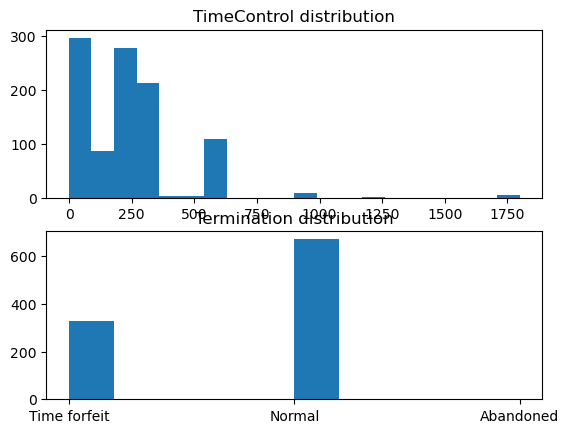

In [52]:
ax1 = plt.subplot(211)
time_control = [int(tc.split("+")[0]) if tc.split("+")[0] != "-" else -1 for tc in df_games["TimeControl"]]
ax1.hist(time_control, 20)
ax1.set_title("TimeControl distribution")

ax2 = plt.subplot(212)
ax2.hist(df_games["Termination"])
ax2.set_title("Termination distribution")

